In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Display full text in dataframe columns
pd.set_option("display.max_colwidth", None)

In [3]:
!pip install -q datasets

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
python-lsp-server 1.13.1 requires jedi<0.20.0,>=0.17.2, but you have jedi 0.20.0 which is incompatible.
spyder 6.1.0 requires jedi<0.20.0,>=0.17.2, but you have jedi 0.20.0 which is incompatible.


In [4]:
from datasets import load_dataset

# Download MedDialog
dataset = load_dataset("OpenMed/MedDialog")

dataset

README.md:   0%|          | 0.00/5.62k [00:00<?, ?B/s]

train.json: reconstructing file:   0%|          |  0.00B /  256MB            

train.json: downloading bytes:           |  0.00B            

validation.json: reconstructing file:   0%|          |  0.00B / 28.6MB            

validation.json: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/226557 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/25174 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['patient_message', 'doctor_response', 'dialogue_context'],
        num_rows: 226557
    })
    validation: Dataset({
        features: ['patient_message', 'doctor_response', 'dialogue_context'],
        num_rows: 25174
    })
})

In [5]:
train_df = dataset['train'].to_pandas()
train_df.head()

,patient_message,doctor_response,dialogue_context
0,"What causes azoospermia ?\n\nHello Doctor, I am 30 yrs old and detected with azoospermia, I do not know the root cause yet, however, i never had any problem with intercourse, erection and ejaculation. I have strong sexdrive, so on the days i do not do sex with my wife I masterbate. I do sometime feel pain in my right ball (testis) after sex or masterbation (may be 2 times a month) from past 2 yrs. I am also hypothyroid taking does of 50 since last year. However, i do not know when thyroid problem started. I am not sure that above information is how much resourcefull but if possible can u suggest me what kind azoospermia i might be having and can it be curable? Also i have semen test only once and As the sample collection was in room at test center and i was not comfertable, so would it a chance that i didnot ejaculate sperm with semen. Also my semen repert says. viscosity high and liquification: incomple.... pls help with suggestions. Thanks Deep","Hi,As you got complete absence of sperms in the semen, there might be having few possibilities,There might be having atrophy of testicles might be due to injury in testicles or h/o mumps in the past.There might be having blockade of tubes carrying sperms.Consult urologist and get examined.Ultra sound and biopsy might required.Ok and take care.",
1,"Which treatment is advisable for rheumatic arthritis ?\n\nSir, I am from Kolkata. My mother 65 yrs suffering from rheumatic artharitis since last nine years. Presently she is bedridden. I want an appointment with Dr. John Matheu in an emergency basis on or after 16- 24 June. kindly help me . with regards, Subir Kundu 094347 30572 subirkundu300924@gmail.com",hi in case of RA tell me what is your diet control and what kind of medicin she taking by diet control and medicine we improve the life style by improving pain,
2,"Is painful blister rash related to shingles or reaction from mucinex?\n\nMy boyfriend has what seems like a pollen allergy; ie. sore throat, congestion, sneezing etc.for over 6 wks. Never had allergie before. He took mucinex and has developed a painful blister rash ( on one side, 3"" x2"").. Could this be shingles? or reaction from mucinex? , he had shingles and chicken pox when he was very young.He is now 59yrs old.","Hello, It seems to be shingles most likely. I would recommend you to upload the pictures of the affected area under the premium section of the site so that I can have a clearer picture of the condition and can guide you accordingly. Hope I have answered your query. Let me know if I can assist you further. Take care Regards, Dr Asmeet Kaur Sawhney, Dermatologist",
3,"13 year old with hives and swelling. Allergic to antibiotics? Gave celestone shot. Rashes returning. What to do?\n\nMy 13 year old daughter is having an allergic reaction to something. Doctor believes it could be the antibiotics she was taking. He gave her a celestone shot and told me to watch her closely at 10am. The swelling and hives mostly went away. Now at 10 ish the hives and swelling are returning. I have given her a 25mg Benadryl but am super worried. Why did the rash come back and how long will it take to go away. Also, if it is a reaction to the amoxicillin how long will it take to get it out of her system. Please help to ease a worried mothers mind.",It takes 3-4 wek to wash out the eefect of drug allergie give lot of water preferably hot Give anti allergics fexofenadine 120 mg daily for 3 - 4 week can apply hisocalamine and mmtasone ointment on afcted parts,
4,"Q. Can Yasmin birth control pill be used as an emergency contraceptive pill?\n\nHello doctor, My fiancee and I had unprotected sex a few days back, but I did not ejaculate inside her. Just to be on the safer side, we wanted to use the emergency contraceptive pill. But due to some restriction in the country where we live, Plan B or emergency contraceptive pills are not available. I read that Yasmin, which is used as a regular co

In [6]:
train_df.shape

(226557, 3)

In [7]:
train_df.columns

Index(['patient_message', 'doctor_response', 'dialogue_context'], dtype='object')

In [8]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226557 entries, 0 to 226556
Data columns (total 3 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   patient_message   226557 non-null  object
 1   doctor_response   226557 non-null  object
 2   dialogue_context  226557 non-null  object
dtypes: object(3)
memory usage: 5.2+ MB


In [11]:
duplicates = train_df.duplicated().sum()

In [10]:
empty_message = (train_df['patient_message'].str.split()=='').sum()

In [12]:
print('Empty Messages:',empty_message)
print('Number of Duplicate Values:',duplicates)

Empty Messages: 0
Number of Duplicate Values: 7860


In [13]:
train_df = train_df.drop_duplicates().reset_index(drop = True)

In [14]:
print('New shape:',train_df.shape)

New shape: (218697, 3)


In [15]:
train_df['word_count'] = train_df['patient_message'].apply(lambda x: len(str(x).split()))

train_df['word_count'].describe()

count    218697.000000
mean         93.319963
std          50.337206
min           5.000000
25%          65.000000
50%          79.000000
75%         105.000000
max         544.000000
Name: word_count, dtype: float64

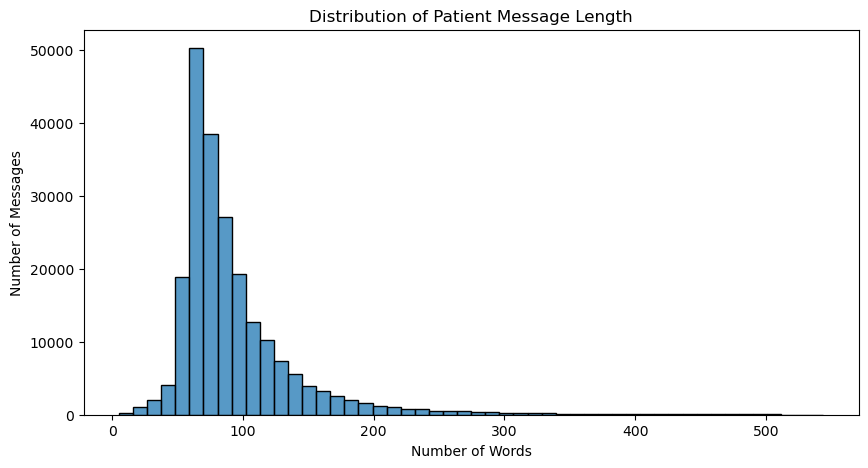

In [16]:
plt.figure(figsize=(10,5))

sns.histplot(train_df["word_count"], bins=50)

plt.title("Distribution of Patient Message Length")
plt.xlabel("Number of Words")
plt.ylabel("Number of Messages")

plt.show()